# AI 221 Assignment 10: Bayesian Optimization of Neural Network Hyperparameters

<b>Description:</b> This notebook demonstrates once again on the classification of human activity using neural networks, but this time, focusing on Bayesian optimization of the hyperparameters. Dataset used is the "Human Activity Recognition Using Smartphones" Dataset that can be downloaded from https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones.
<br>
<br>
<b>Author:</b> Adrian Josele G. Quional
<br>
<b>Submitted to:</b> Dr. Jon Dewitt E. Dalisay
<br>
<b>Semester/Year:</b> 2nd Semester/2024-2025

In [1]:
# imports

# libraries for manipulation of data, displaying of plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# to time the hyperparameter search
import time

# libraries for MLP classifer training and evaluation
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.base import clone

# for random search
from scipy import stats

# for Bayesian optimization of hyperparameters
import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_slice, plot_contour, plot_edf

# to supress Optuna warnigns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning)

## Data Loading

This section loads the preprocessed data from the previous assignment.

In [2]:
output_csv_train = 'har_train.csv' # name of output train CSV
output_csv_test = 'har_test.csv' # name of output test CSV

# loading preprocessed data
train_df = pd.read_csv(output_csv_train)
test_df = pd.read_csv(output_csv_test)

print("Training data:")
display(train_df.head())
print()
print("Test data:")
display(test_df.head())

Training data:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity,subject
0,0.200642,-0.063683,-0.419628,-0.868814,-0.939441,-0.737529,-0.859817,-0.939019,-0.766437,-0.856036,...,-0.276399,-0.360603,0.062940,-0.778427,-0.026080,-0.687219,0.407946,-0.007568,STANDING,1
1,0.055948,0.031486,-0.253908,-0.875426,-0.923902,-0.849304,-0.868531,-0.921998,-0.848928,-0.871359,...,-0.767990,0.133011,-0.021461,-1.218805,1.484470,-0.694138,0.409117,0.007875,STANDING,1
2,0.073515,-0.043416,-0.076295,-0.869039,-0.907760,-0.893785,-0.863137,-0.898854,-0.896701,-0.863323,...,-0.438316,-0.377840,0.391976,0.151207,1.704201,-0.702239,0.410288,0.026502,STANDING,1
3,0.066696,-0.208422,-0.249712,-0.870626,-0.940022,-0.921805,-0.864503,-0.938124,-0.925279,-0.863323,...,0.463155,-0.135025,-0.033637,1.037851,-1.003019,-0.701684,0.414650,0.031714,STANDING,1
4,0.030469,0.027587,-0.109848,-0.875188,-0.934878,-0.921343,-0.867384,-0.931789,-0.928028,-0.870260,...,-0.240313,0.340406,0.268486,1.125918,-1.276282,-0.700152,0.425463,0.045225,STANDING,1



Test data:


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity,subject
0,-0.246388,-0.136979,1.668462,-0.742061,-0.814056,-0.150313,-0.759330,-0.819786,-0.164580,-0.781407,...,-0.262320,-0.006596,0.358560,-1.372126,0.579845,-0.450322,0.733571,-0.005244,STANDING,2
1,0.164235,0.111059,-0.175548,-0.824544,-0.908299,-0.812607,-0.840212,-0.908595,-0.820280,-0.781407,...,0.098679,-0.273719,0.034161,-0.728470,1.938673,-0.407493,0.748840,-0.098112,STANDING,2
2,0.014187,-0.204740,-0.159111,-0.865561,-0.913208,-0.855099,-0.858146,-0.913397,-0.862926,-0.864367,...,-0.050207,-0.129586,0.446413,0.091042,0.316041,-0.416639,0.744605,-0.081803,STANDING,2
3,-0.059637,-0.365579,-0.147960,-0.867620,-0.919858,-0.865472,-0.860199,-0.921086,-0.876002,-0.863173,...,-0.360349,-0.076465,0.339639,0.544845,0.632687,-0.409180,0.758155,-0.073784,STANDING,2
4,0.004908,-0.248785,-0.359980,-0.865636,-0.908274,-0.892234,-0.857457,-0.903555,-0.896405,-0.863173,...,-0.719531,-0.032386,-0.094211,1.196836,-0.235517,-0.396070,0.780371,-0.062135,STANDING,2


## Classification using Neural Network (no dimensionality reduction)

This section creates, fits, and evaluates various neural network models for classification of human activity using all of the features of the dataset (no dimensionality reduction). Specifically, the fitting of the neural networks would focus on the different methods of hyperparameter search. After fitting, the different methods would be compared.

In [3]:
# separating features and target
X_train = train_df.drop(['activity', 'subject'], axis=1).to_numpy()
y_train = train_df['activity'].to_numpy()
X_test = test_df.drop(['activity', 'subject'], axis=1).to_numpy()
y_test = test_df['activity'].to_numpy()

# verifying the separated features and target
print(f"X_train array (first row): {X_train[0, :]}")
print(f"X_train shape: {X_train.shape}")
print()
print(f"y_train array (first row): {y_train[0]}")
print(f"y_train shape: {y_train.shape}")
print()
print(f"X_test array (first row): {X_test[0, :]}")
print(f"X_test shape: {X_test.shape}")
print()
print(f"y_test array (first row): {y_test[0]}")
print(f"y_test shape: {y_test.shape}")

X_train array (first row): [ 0.20064157 -0.0636826  -0.41962845 -0.86881389 -0.93944133 -0.73752941
 -0.85981668 -0.93901851 -0.76643665 -0.85603599 -0.92598454 -0.63737881
  0.90600869  0.86865566  0.73838305 -0.885916   -0.69303073 -0.77569634
 -0.67049557 -0.8339624  -0.92541678 -0.8075475  -0.64989794 -1.23822642
 -1.17999502  3.41252516 -3.87617503  1.63245448 -0.82156997  1.10007176
 -1.16830223  0.49870233 -0.34175676  0.9418653  -2.30437127  1.92773254
 -0.48226779  1.38089495  1.89952314  1.44227747  0.57917174 -0.40795505
  0.06169232 -0.26575265 -0.30641857  0.55324213 -0.25631866 -0.32876708
  0.41071019  0.56444743 -0.43825441  0.07486024  0.58772896 -0.39615055
 -0.06894335 -0.74089002  0.66311366 -0.55039182 -0.52947025 -0.22854336
 -0.35414612  0.24876141 -0.91072978 -0.46503661  2.01424495 -0.34949775
  0.1827801  -0.00904066 -0.16013948 -1.36705289  1.30359406 -1.20629389
  1.07253348 -2.08957597  2.07244699 -2.03169313  1.96524683  0.55041437
  0.76914333  1.27570673

In [4]:
# defining a base model
base_mlp = MLPClassifier(max_iter=300, random_state=6)

# defining Stratified CV as the CV strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=6)

# defining a fair search space:

# for Grid Search
param_grid = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "activation": ["relu", "tanh"],
    "alpha": [1e-4, 1e-3, 1e-2],
    "learning_rate_init": [0.001, 0.01, 0.1]
}

# for Random Search
# Random Search uses distributions instead of full grid
param_distributions = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "activation": ["relu", "tanh"],
    "alpha": stats.uniform(1e-4, 1e-2),
    "learning_rate_init": stats.uniform(0.001, 0.1)
}

# results container for all searches
results = {}

# helper function to run search and store results (especially for Grid Search and Random Search)
def run_search(searcher, name):
    print(f"\n🔍 Running {name}...")
    start = time.time()
    searcher.fit(X_train, y_train)
    end = time.time()
    elapsed = elapsed = end - start

    y_pred = searcher.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)

    print(f"\n⏱️ Elapsed time for {name}: {elapsed:.2f} seconds")
    print(f"🎯 Neural network test accuracy via {name} : {test_acc:.4f}")    
    print(f"📌 Best parameters: {searcher.best_params_}")
    print("\n🧪 Test set performance:")

    # classification report
    class_report = classification_report(y_test, y_pred, output_dict=True)
    class_report_df = pd.DataFrame(class_report).transpose()

    plt.figure(figsize=(10, 5))
    sns.heatmap(class_report_df.iloc[:, :-1] * 100, annot=True, cmap='viridis', fmt=".1f")
    plt.title(f"{name} - Classification Report Heatmap")
    plt.tight_layout()
    plt.show()

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=searcher.classes_, yticklabels=searcher.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.show()

    results[name] = {
        "searcher": searcher,
        "accuracy": test_acc,
        "time": elapsed,
        "y_pred": y_pred,
    }

    return searcher

### Grid Search


🔍 Running Grid Search...

⏱️ Elapsed time for Grid Search: 214.43 seconds
🎯 Neural network test accuracy via Grid Search : 0.9464
📌 Best parameters: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}

🧪 Test set performance:


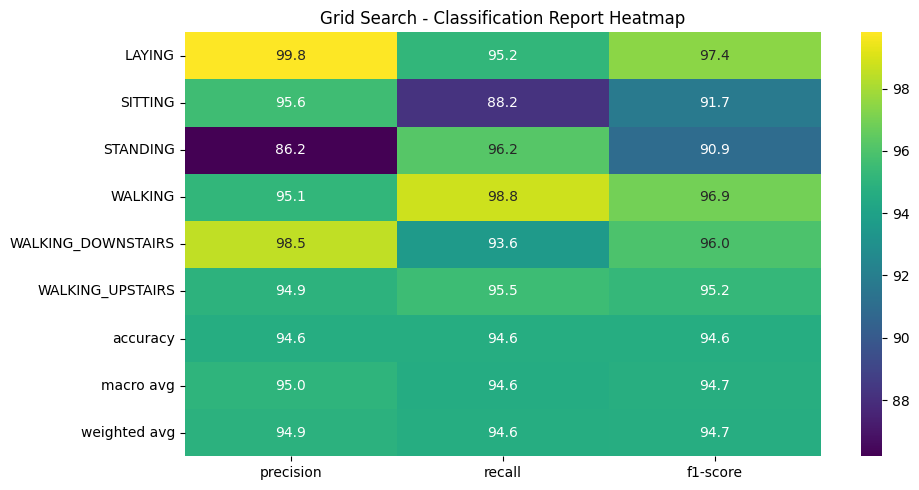

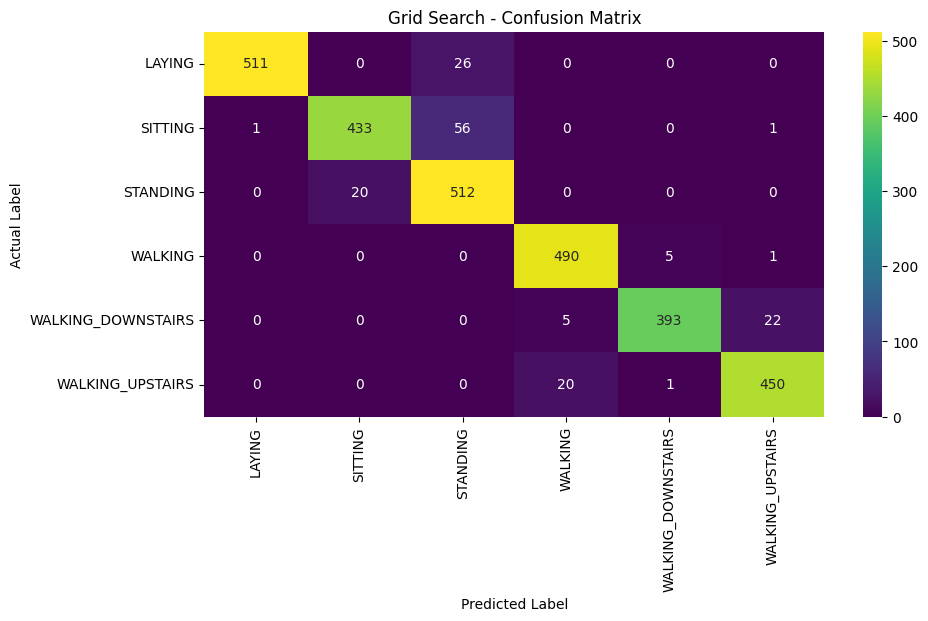

In [5]:
# defining Grid Search
grid_search = GridSearchCV(clone(base_mlp), param_grid=param_grid, cv=cv_strategy, n_jobs=-1)

# running Grid Search and evaluating best MLP found via Grid Search
grid_search = run_search(grid_search, "Grid Search")

Based on Grid Search, the following are the hyperparameters of the best MLP it has searched:
* Activation function of all neurons: tanh
* Alpha: 0.01
* Number of hidden layers: 1
* Number of neurons in Hidden Layer 1: 100
* Learning rate: 0.01

Search time via Grid Search: 214.43 seconds (3.57 minutes)

Test accuracy: 94.6%

### Random Search


🔍 Running Random Search...

⏱️ Elapsed time for Random Search: 39.97 seconds
🎯 Neural network test accuracy via Random Search : 0.9511
📌 Best parameters: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (50,), 'alpha': 0.001, 'activation': 'tanh'}

🧪 Test set performance:


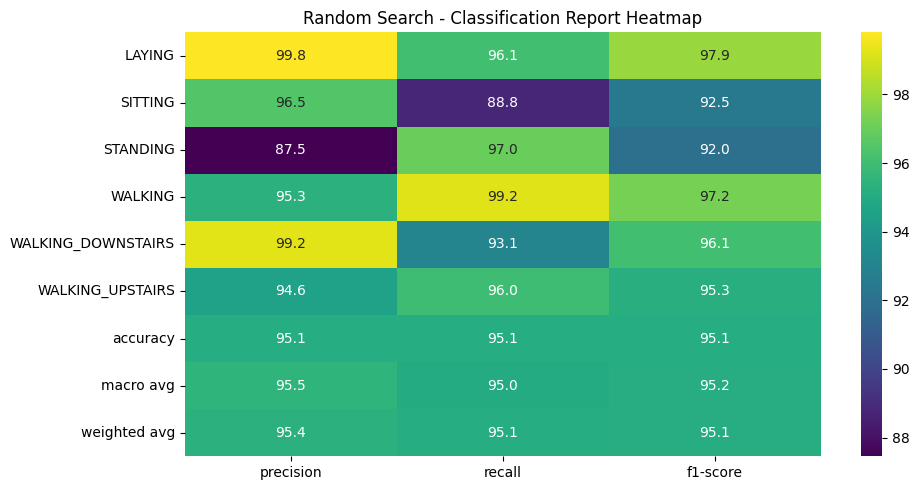

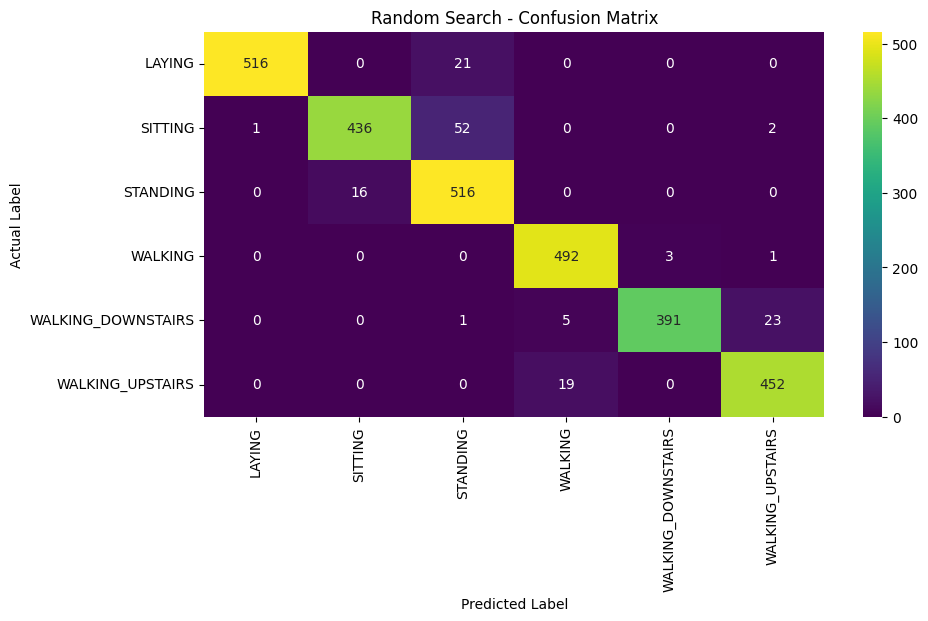

In [6]:
# defining Random Search
random_search = RandomizedSearchCV(clone(base_mlp), param_distributions=param_grid, n_iter=10, cv=cv_strategy, random_state=6, n_jobs=-1)

# running Random Search and evaluating best MLP found via Random Search
random_search = run_search(random_search, "Random Search")

Based on Random Search, the following are the hyperparameters of the best MLP it has searched:
* Activation function of all neurons: tanh
* Alpha: 0.01
* Number of hidden layers: 1
* Number of neurons in Hidden Layer 1: 50
* Learning rate: 0.001

Search time via Grid Search: 39.97 seconds (0.67 minute)

Test accuracy: 95.1%

### Bayesian Search

[I 2025-04-07 00:52:22,908] A new study created in memory with name: no-name-4b07f408-c858-403d-9261-6cf81b2bebfb



🔍 Running Bayesian (Optuna) Search...


[I 2025-04-07 00:53:07,592] Trial 0 finished with value: 0.9861263336061821 and parameters: {'hidden_layer_sizes': (100,), 'activation': 'relu', 'alpha': 0.003729705742295165, 'learning_rate_init': 0.0007871622289723483}. Best is trial 0 with value: 0.9861263336061821.
[I 2025-04-07 00:53:13,322] Trial 1 finished with value: 0.9507619880039032 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'relu', 'alpha': 0.00017208216174629696, 'learning_rate_init': 0.036067446223465915}. Best is trial 0 with value: 0.9861263336061821.
[I 2025-04-07 00:53:19,889] Trial 2 finished with value: 0.965582948339091 and parameters: {'hidden_layer_sizes': (50,), 'activation': 'relu', 'alpha': 0.0011554641690673562, 'learning_rate_init': 0.03764072389091181}. Best is trial 0 with value: 0.9861263336061821.
[I 2025-04-07 00:53:31,015] Trial 3 finished with value: 0.9842215717014202 and parameters: {'hidden_layer_sizes': (50, 50), 'activation': 'tanh', 'alpha': 0.00584502450312068, 'learning_rate_i


⏱️ Elapsed time for Bayesian (Optuna) Search: 137.50 seconds
🎯 Neural network test accuracy via Bayesian (Optuna) Search: 0.9447
📌 Best parameters: {'hidden_layer_sizes': (100,), 'activation': 'relu', 'alpha': 0.003729705742295165, 'learning_rate_init': 0.0007871622289723483}

🧪 Test set performance:


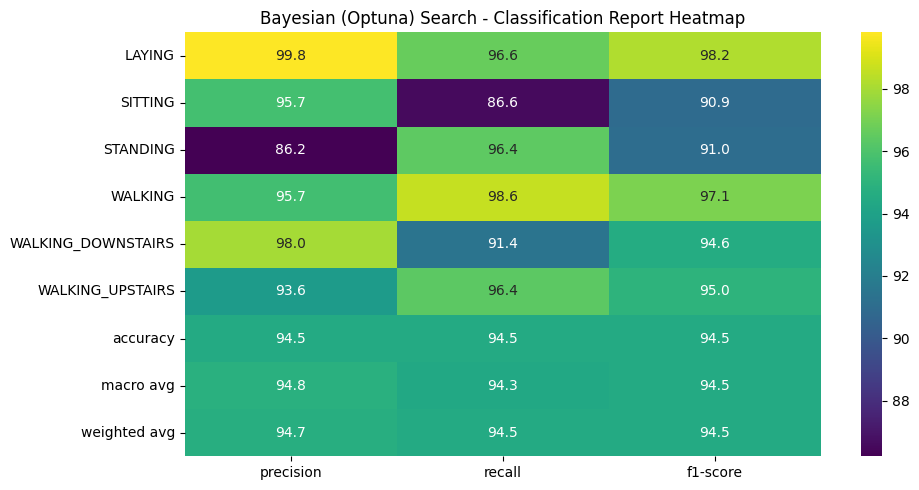

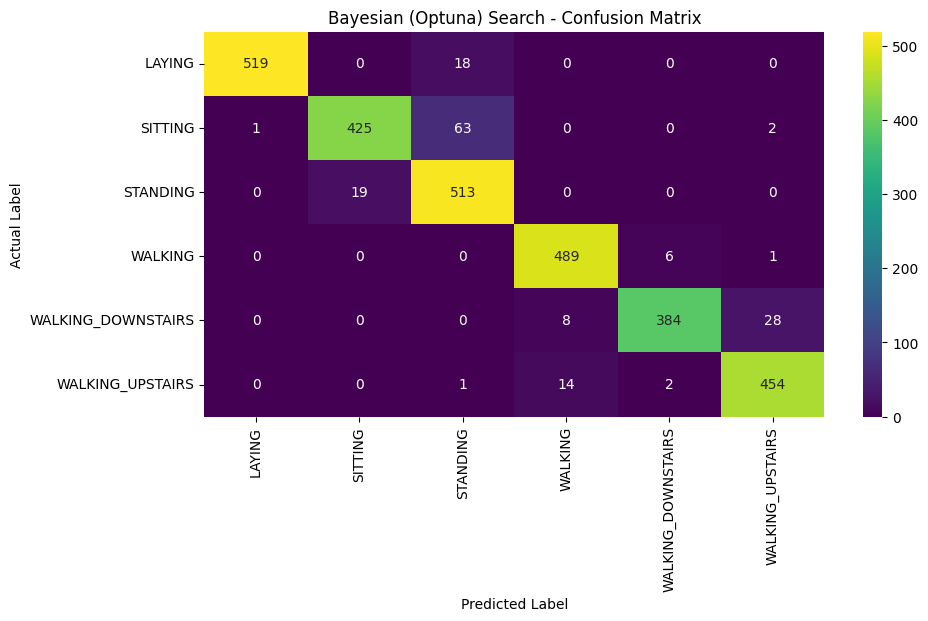

In [7]:
# defining objective for Bayesian (Optuna) Search
def objective(trial):
    mlp = clone(base_mlp)
    hidden_layer_sizes = trial.suggest_categorical("hidden_layer_sizes", [(50,), (100,), (50, 50)])
    activation = trial.suggest_categorical("activation", ["tanh", "relu"])
    solver = "adam"
    alpha = trial.suggest_float("alpha", 1e-4, 1e-2, log=True)
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-1, log=True)

    mlp.set_params(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        alpha=alpha,
        learning_rate_init=learning_rate_init
    )

    scores = []
    for train_idx, val_idx in cv_strategy.split(X_train, y_train):
        mlp.fit(X_train[train_idx], y_train[train_idx])
        y_pred = mlp.predict(X_train[val_idx])
        scores.append(accuracy_score(y_train[val_idx], y_pred))

    return np.mean(scores)

print("\n🔍 Running Bayesian (Optuna) Search...")

optuna_start = time.time()
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)
optuna_end = time.time()
optuna_elapsed = optuna_end - optuna_start
print(f"\n⏱️ Elapsed time for Bayesian (Optuna) Search: {optuna_elapsed:.2f} seconds")

best_params = study.best_params 
optuna_mlp = clone(base_mlp).set_params(**best_params, solver="adam")
optuna_mlp.fit(X_train, y_train)
optuna_preds = optuna_mlp.predict(X_test)
optuna_acc = accuracy_score(y_test, optuna_preds)
print(f"🎯 Neural network test accuracy via Bayesian (Optuna) Search: {optuna_acc:.4f}")

print(f"📌 Best parameters: {best_params}")

print("\n🧪 Test set performance:")

# classification report
bayesian_class_report = classification_report(y_test, optuna_preds, output_dict=True)
bayesian_class_report_df = pd.DataFrame(bayesian_class_report).transpose()

plt.figure(figsize=(10, 5))
sns.heatmap(bayesian_class_report_df.iloc[:, :-1] * 100, annot=True, cmap='viridis', fmt=".1f")
plt.title("Bayesian (Optuna) Search - Classification Report Heatmap")
plt.tight_layout()
plt.show()

# confusion matrix
optuna_cm = confusion_matrix(y_test, optuna_preds)

plt.figure(figsize=(10, 5))
sns.heatmap(optuna_cm, annot=True, fmt="d", cmap="viridis", xticklabels=optuna_mlp.classes_, yticklabels=optuna_mlp.classes_)
plt.title("Bayesian (Optuna) Search - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

results["Bayesian Search"] = {
    "searcher": study,
    "accuracy": optuna_acc,
    "time": optuna_elapsed,
    "y_pred": optuna_preds,
}

Based on Bayesian (Optuna) Search, the following are the hyperparameters of the best MLP it has searched:
* Activation function of all neurons: relu
* Alpha: 0.0037
* Number of hidden layers: 1
* Number of neurons in Hidden Layer 1: 100
* Learning rate: 0.00079

Search time via Grid Search: 137.50 seconds (2.29 minutes)

Test accuracy: 94.5%

## Comparison of the three hyperparameter search methods

This section compares the different hyperparameter search methods.

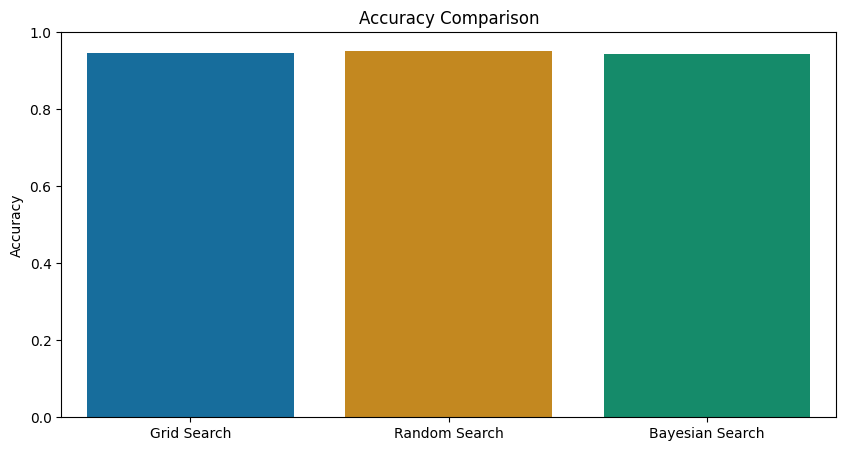

In [8]:
# accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=[r["accuracy"] for r in results.values()], hue=list(results.keys()), legend=False, palette="colorblind")
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

As can be seen, all of the search methods yielded almost the same test accuracy score for the neural network.

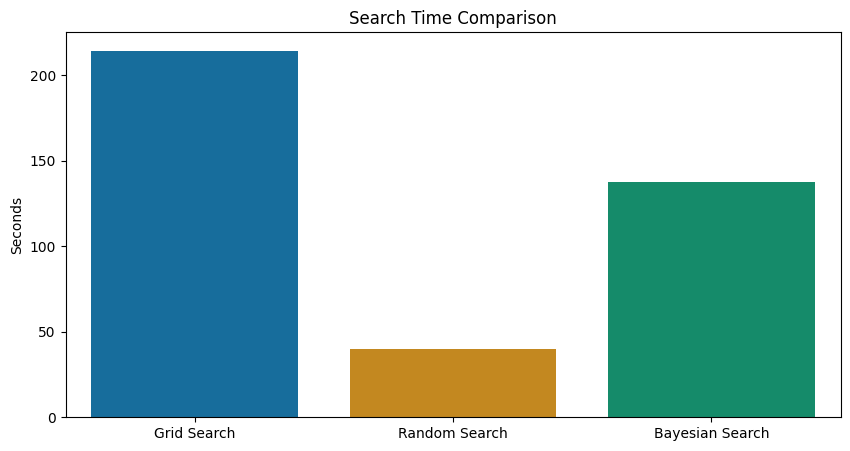

In [9]:
# time comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=[r["time"] for r in results.values()], hue=list(results.keys()), legend=False, palette="colorblind")
plt.title("Search Time Comparison")
plt.ylabel("Seconds")
plt.show()

In terms of search times, the different among the three methods can be seen. From the plot above, it is evident that Random Search had the fastest search time compared to both Grid Search and Bayesian Search. Between the latter two, Bayesian Search yielded a shorter (second among the three) search time. 

Comparing Random Search and Bayesian Search, the latter will yield a longer search time since each trial depends on prior results, using a surrogate model to choose the next best set of hyperparameters which would incur overhead from modeling and decision-making between trials. Random Search, on the other hand, picks hyperparameter combinations randomly and independently. If it gets lucky, it will acquire the best hyperparameters in a quicker way; however, getting the "best" hyperparameter is not guaranteed since it relies on chance. As for Grid Search, no doubt that it took the longest since it tries all hyperparameter combinations, without regard to the previous trials.

In summary, if time is of utmost consideration, Random Search would still be the best search method to use. However, if a more "intelligent" way is preferred to be used, Bayesian Search is recommended since every trial depends on the previous ones - it leans from its previous runs.

<Figure size 1000x500 with 0 Axes>

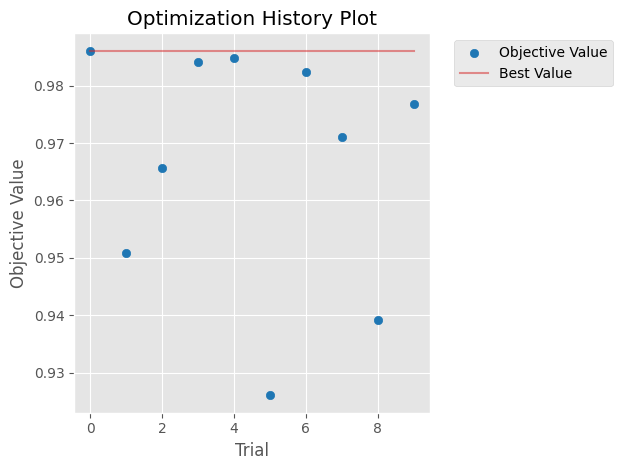

In [10]:
# Optuna-specific visualization
# plotting optimization history
plt.figure(figsize=(10, 5))
plot_optimization_history(study)
plt.tight_layout()
plt.show()

The plot shows the progress of Bayesian Search over time with regards to the objective value (accuracy in this case). As can be seen, the search seems to be all over the place. Still, it attained the best value.

<Figure size 1000x500 with 0 Axes>

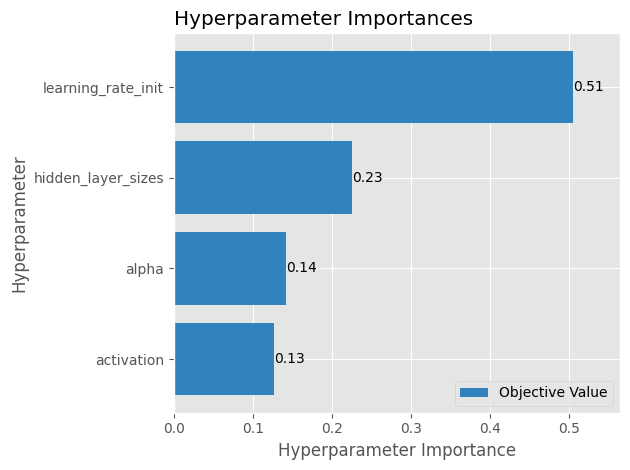

In [11]:
# Optuna-specific visualization
# plotting parameter importance
plt.figure(figsize=(10, 5))
plot_param_importances(study)
plt.tight_layout()
plt.show()

From the plot above, it shows that learning rate is the most important hyperparameter considered by Bayesian Search which contributed a lot to finding the best objective value.

## Summary

* In this assignment, classification using a neural network is conducted on the HAR Dataset from UCI Machine Learning Repository.
* Specifically, this assignment focused on Bayesian optimization of the hyperparameters. This is compared to the two other hyperparameter search methods: Grid Search and Random Search.
* For Bayesian optimization, the `Optuna` library is used. In initial runs though, `scikit-optimize` is used, particularly the `BayesSearchCV` method, in parallel to `GridSearchCV` and `RandomSearchCV`. However, it has been found out that it's quite limited and restricting in terms of the data types of the parameters to be tuned (for example, varying number of hidden layers). Because of this observed limitation, `Optuna` is instead used.
* For a comparison of the three search methods, all three yielded almost the same test accuracy for the neural network. However, in terms of search times, the difference is noticeable. Random Search yielded the shortest search time while Bayesian Search yielded a longer search time than Random Search. This is expected though since Bayesian Search relies on previous trials which yielded an additional overhead. Random Search, on the other hand, tries hyperparameter combinations randomly - it might get lucky or unlucky. Bayesian Search does a more intelligent search as the current run depends on previous trials, at the expense of a longer search time. Grid Search, no doubt, took the longest time since it tries all possible hyperparameter combinations in the defined search space.
* The following are the hyperparameters of the best MLP obtained usingg different search methods:
    * Grid Search:
        * Activation function of all neurons: tanh
        * Alpha: 0.01
        * Number of hidden layers: 1
        * Number of neurons in Hidden Layer 1: 100
        * Learning rate: 0.01
    * Random Search:
        * Activation function of all neurons: tanh
        * Alpha: 0.01
        * Number of hidden layers: 1
        * Number of neurons in Hidden Layer 1: 50
        * Learning rate: 0.001
    * Bayesian (Optuna) Search:
        * Activation function of all neurons: relu
        * Alpha: 0.0037
        * Number of hidden layers: 1
        * Number of neurons in Hidden Layer 1: 100
        * Learning rate: 0.00079